# Clustering of RNA Structures

This notebook provides a starting point for the different tasks involved in clustering RNA secondary structures.

## Tasks covered
1. **Data loading** – load RNA sequences and secondary structures
2. **Feature extraction** – convert dot-bracket notation into numerical feature vectors
3. **Pairwise distance computation** – compare structures using edit distance and base-pair distance
4. **Clustering** – apply K-means and hierarchical (agglomerative) clustering
5. **Evaluation** – measure cluster quality with silhouette score and dendrogram
6. **Visualisation** – PCA projection and heatmap of the distance matrix

## 1. Imports and setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import RNA
import time

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn_extra.cluster import KMedoids

%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Data loading

RNA secondary structures are commonly stored in **dot-bracket** notation alongside the nucleotide sequence.
Replace the sample data below with your own dataset (e.g. from a FASTA/Stockholm file or a database query).

In [ ]:
sequence = "GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGGUCCUGUGUUCGAUCCACAGAAUUCGCACCA"

In [ ]:
rna_sequences = [
    # tRNA-Phe (levure S. cerevisiae) — structure en feuille de trèfle classique
    # Source: RCSB PDB 1EHZ
    ("tRNA_Phe", "GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGGUCCUGUGUUCGAUCCACAGAAUUCGCACCA"),

    # 5S rRNA (E. coli) — hélices multiples, structure compacte
    # Source: RFAM RF00001, accession J01695
    ("5S_rRNA", "UGCCUGGCGGCCGUAGCGCGGUGGUCCCACCUGACCCCAUGCCGAACUCAGAAGUGAAACGCCGUAGCGCCGAUGGUAGUGUGGGGUCUCCCCAUGCGAGAGUAGGUCAGGC"),

    # Hammerhead ribozyme (Schistosoma mansoni) — motif catalytique
    # Source: RFAM RF00008
    ("Hammerhead_ribozyme", "AACUGAUGAGUCCGUGAGGACGAAACAGC"),

    # U1 snRNA (humain) — impliquée dans l'épissage
    # Source: RFAM RF00003, accession X59350
    ("U1_snRNA", "AUACUUACCUGGCAGGGGAGAUACCAUGAUUUGCGUAAGUCUCUUCAGUGCAUUGCAGGUGUAGUGCUCCUGGGCAAGUCCCCAAAGGAGCUAAUUUCCAUGGGGCUAAGUGAGAAUAUCAAAGCUAGUUUCUCCAAGGUGCAGUCAGAGCUGCUUCGCACUUUCGGUGUCUGCUCUUCGCAGCUUCGCAGCUUCGGUCUUCUGCAUGGGAGAGCUCUGCAAAAGCGAAGCGGUGCAGAGCAGAGUCCCGGUCUGGAAGUGAGAAUAUCUCAAAGCUAGUUUCUCCGAGGUGCAGUCAGAGCUGCUUCGCACUUUCGGUGUCUGCUCUUCGCAGCUUCGCAGCUUCGGUCUUCUGCAUGGGAGAGCUCUGCAAAAGCGAAGCGGUGCAGAGCAGAGUCCCGGUCUGGAAGUGAGAAUAUCUCAAAGCUAGUUUCUCCAAGGUGCAGUCAGAGCUGCUUCGCACUUUCGGUGUCUGCUCUUCGCAG"),

    # Purine riboswitch aptamer (Bacillus subtilis) — change de conformation selon ligand
    # Source: RFAM RF00167, accession AY330909
    ("Purine_riboswitch", "UUAUAUAACUCAUAUCAAUAUGGUCUAAAAUAAUGCGCUAACAGUGUAGAUGAAAACAUAGCCCUAGGUGCUGUCGAGCUUUCGCAGCUUCGGCUUACAGGCAUAUGGGCAUCAAGCUAUUUAGCCGAGAUUAAAGAGAUUCGCUGUUGAAAUGUCGAAGACAGCGCAGCUUCGGCUU"),

    # Iron response element (IRE) — courte tige-boucle régulatrice
    # Source: RFAM RF00037
    ("IRE", "CUUCCUUCAGUGCUUCGGAAGG"),
]

### 2a. Self coded Partitioning

In [3]:
def calculate_partition_function(unpaired_probs, paired_probs, beta, m=3):
    """
    Computes the partition function Z[i,j] for an RNA alignment.
    Based on the recursion: Z[i,j] = Z[i,j-1]*exp(beta*UNP(j)) + sum(...)
    """
    n = len(unpaired_probs)
    # Z matrix including an extra index for Z[i, i-1] = 1.0 cases
    Z = np.zeros((n + 1, n + 1), dtype=np.float64)
    
    # Initialization
    for i in range(n):
        Z[i, i] = np.exp(beta * unpaired_probs[i])
        Z[i, i-1] = 1.0
    if n > 0: Z[n, n-1] = 1.0

    # DP Recursion
    for length in range(1, n):
        for i in range(n - length):
            j = i + length
            
            # Case 1: j is unpaired
            # Z[i, j] = Z[i, j-1] * exp(beta * UNP(j))
            z_val = Z[i, j-1] * np.exp(beta * unpaired_probs[j])
            
            # Case 2: j is paired with some k
            # sum over k: Z[i, k-1] * exp(beta * PAIR(k,j)) * Z[k+1, j-1]
            for k in range(i, j - m):
                # Handle the k=i case where Z[i, k-1] is Z[i, i-1] = 1.0
                term_left = Z[i, k-1] if k > i else 1.0
                z_val += term_left * np.exp(beta * paired_probs[k, j]) * Z[k+1, j-1]
                
            Z[i, j] = z_val
            
    return Z

def stochastic_traceback(i, j, Z, unpaired_probs, paired_probs, beta, structure, m=3):
    """
    Produces a random substructure for indices i..j based on partition function Z.
    """
    if j < i:
        return

    # Select a random float for selecting the case
    x = np.random.uniform(0, Z[i, j])
    
    # Check Case: j is unpaired [cite: 306]
    z_unpaired = (Z[i, j-1] if j > i else 1.0) * np.exp(beta * unpaired_probs[j])
    
    if x < z_unpaired:
        stochastic_traceback(i, j-1, Z, unpaired_probs, paired_probs, beta, structure, m)
        return

    # Check Case: j is paired with k [cite: 309]
    cumulative_z = z_unpaired
    for k in range(i, j - m):
        term_left = Z[i, k-1] if k > i else 1.0
        z_paired = term_left * np.exp(beta * paired_probs[k, j]) * Z[k+1, j-1]
        cumulative_z += z_paired
        
        if x < cumulative_z:
            structure[k] = "("
            structure[j] = ")"
            # Recursively sample the two independent sub-problems
            stochastic_traceback(i, k-1, Z, unpaired_probs, paired_probs, beta, structure, m)
            stochastic_traceback(k+1, j-1, Z, unpaired_probs, paired_probs, beta, structure, m)
            return

def sample_structures(unpaired_probs, paired_probs, beta, num_samples=1000, m=3):
    """Generates a list of sampled RnaMolecule structures."""
    n = len(unpaired_probs)
    Z = calculate_partition_function(unpaired_probs, paired_probs, beta, m)
    
    samples = []
    for _ in range(num_samples):
        struct_list = ["."] * n
        stochastic_traceback(0, n - 1, Z, unpaired_probs, paired_probs, beta, struct_list, m)
        samples.append("".join(struct_list))
    return samples

In [4]:
def db2pairs(dbstring):
    base_pairs = []
    stack = []
    
    for index, char in enumerate(dbstring):
        position = index + 1  
        
        if char == '(':
            stack.append(position)
        elif char == ')':
            if not stack:
                raise ValueError(f"Error at position {position} : No matching opening parenthesis")
            opening_pos = stack.pop()
            base_pairs.append((opening_pos, position))
        elif char == '.':
            continue
        else:
            raise ValueError(f"Incompatible character '{char}' detected at the {position}.")
            
    if stack:
        raise ValueError(f"Error : {len(stack)} No closed parenthesis (positions : {stack}).")
        
    return sorted(base_pairs)

def probability_matrix(samples):
    """Estimates base pair probabilities from samples."""
    n = len(samples[0])
    prob_matrix = np.zeros((n, n))
    
    for s in samples:
        pairs = db2pairs(s) 
        for i, j in pairs:
            prob_matrix[i-1, j-1] += 1
            
    prob_matrix /= len(samples)
    return prob_matrix

### 2b. McCaskill algorithm using the ViennaRNA package

In [ ]:
md = RNA.md()  

fc = RNA.fold_compound(sequence, md)

# McCaskill algorithm 
(propensity, ensemble_energy) = fc.pf()

# Base-pairing probability matrix 
bpp_matrix = fc.bpp()

print(f"Ensemble Free Energy: {ensemble_energy:.2f} kcal/mol")
print(f"Probability of base 1 pairing with base 20: {bpp_matrix[1][20]:.4f}")
print("Propensity", propensity)
print("bpp", bpp_matrix)

Ensemble Free Energy: -8.64 kcal/mol
Probability of base 1 pairing with base 20: 0.0005
Propensity ..(((((........)))))(((((((...)))))))...
bpp ((0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.640343715432157e-06, 0.0, 0.0, 0.0, 0.0, 2.410004185660465e-05, 0.003714696211301517, 0.0, 0.0, 0.0, 5.9390471641559526e-05, 2.7592582865121717e-05, 0.0, 0.0004881023543541124, 0.0, 6.176627386760668e-05, 3.2218666960920665e-05, 9.152886501594468e-06, 0.0, 3.780650077304087e-08, 0.0, 0.0, 6.0960504916301e-08, 2.2490047656787905e-08, 0.013961111237572425, 0.0, 5.059886072987132e-05, 0.0, 0.0, 0.0, 3.499967121394817e-05, 0.0013273719742963573, 0.002900185449102967, 2.3317933484071404e-05), (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.421836596690229e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.023777

In [ ]:
def boltzmann_sampling(fold_compound):
    """ 
    return a backtracked structure from a fold_compound where the partition function is already computed
    """ 
    return fold_compound.pbacktrack()

print(boltzmann_sampling(fc))

def sampling_structures(fold_compound, num_samples=1000):
    """Generates a dataframe of sampled RnaMolecule structures."""
    samples = []
    for _ in range(num_samples):
        struct = boltzmann_sampling(fold_compound)
        samples.append(struct)
    df_samples = pd.DataFrame(samples, columns=["structure"])
    return df_samples

# Generate 1000 samples as a dataframe
df_samples = sampling_structures(fc, num_samples=1000)
print(df_samples.head())

.(.((((........)))))(((((((...)))))))...
                                  structure
0  ..(((((........)))))(((((((...)))))))...
1  ..(((((........)))))(((((((...)))))))...
2  ..(((((........)))))(((((((...)))))))...
3  ..(((((........)))))(((((((...)))))))...
4  ..(((((........)))))(((((((...)))))))...


### Comparison of the two matrices

Match of our results of partitioning between bpp matrix and the self coded partitioning matrix.

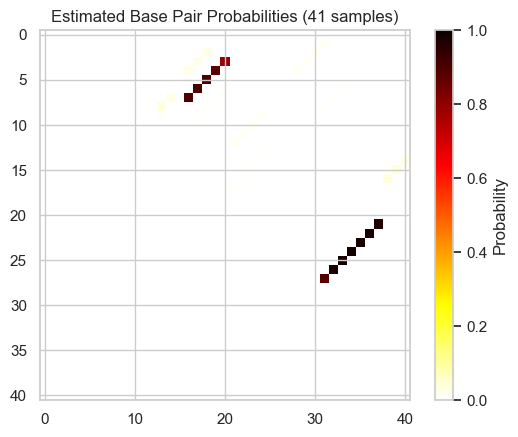

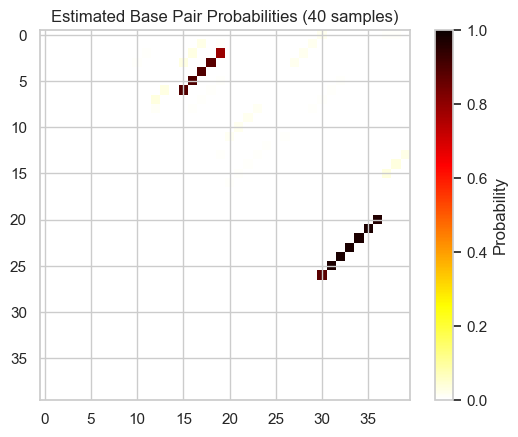

In [37]:
def plot_probability_heatmap(matrix):
    """Visualizes heatmap of base pair probabilities."""
    plt.imshow(matrix, cmap='hot_r', vmin=0, vmax=1)
    plt.title(f"Estimated Base Pair Probabilities ({len(matrix)} samples)")
    plt.colorbar(label="Probability")
    plt.show()

matrix = probability_matrix(df_samples["structure"].tolist())
plot_probability_heatmap(bpp_matrix)
plot_probability_heatmap(matrix)

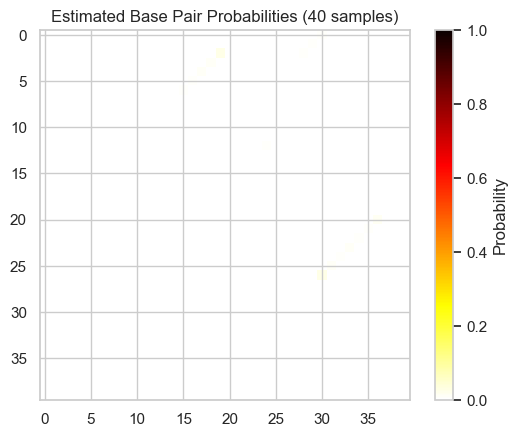

In [9]:
# Mettre la bpp_matric sous forme de matrice de probabilité
bpp_matrix = np.array(bpp_matrix)
#Enlever la première ligne et la première colonne de bpp_matrix pour correspondre à l'indexation 0-based de matrix
reshaped_bpp = bpp_matrix[1:, 1:]
difference_matrix = np.abs(reshaped_bpp-matrix)
plot_probability_heatmap(difference_matrix)

## 3. Feature extraction

We encode each dot-bracket string as a numeric vector:
- `(` → 1
- `)` → -1
- `.` → 0

Sequences of different lengths are zero-padded to the maximum length.

In [38]:
ENCODING = {"(": 1, ")": -1, ".": 0}

def encode_structure(struct: str, max_len: int) -> np.ndarray:
    """Encode a dot-bracket string to a zero-padded numeric array."""
    vec = [ENCODING.get(c, 0) for c in struct]
    vec += [0] * (max_len - len(vec))  # zero-pad
    return np.array(vec, dtype=float)

max_len = df_samples["structure"].str.len().max()
X = np.vstack([encode_structure(s, max_len) for s in df_samples["structure"]])

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (1000, 40)


In [40]:
print("Matrix", X)
print("Length", max_len)

Matrix [[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Length 40


## 4. Pairwise distance computation

Two common distances for RNA structures:
- **Hamming Distance** 
- **Levenshtein distance** on the encoded vectors (proxy)
- **Edit distance** (string edit / Levenshtein) on the raw dot-bracket strings

### 4a. Levenshtein distance

In [30]:
# --- String edit distance (Levenshtein) ---
def edit_distance(s1: str, s2: str) -> int:
    """Compute the Levenshtein edit distance between two strings."""
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, n + 1):
            if s1[i - 1] == s2[j - 1]:
                dp[j] = prev[j - 1]
            else:
                dp[j] = 1 + min(prev[j], dp[j - 1], prev[j - 1])
    return dp[n]

structs = df_samples["structure"].tolist()
n = len(structs)
dist_Levenshtein = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        d = edit_distance(structs[i], structs[j])
        dist_Levenshtein[i, j] = d
        dist_Levenshtein[j, i] = d

print("\nEdit distance matrix:")
print(dist_Levenshtein)


Edit distance matrix:
[[ 0.  8. 10. ... 10. 10. 10.]
 [ 8.  0.  2. ...  2.  4.  2.]
 [10.  2.  0. ...  0.  2.  0.]
 ...
 [10.  2.  0. ...  0.  2.  0.]
 [10.  4.  2. ...  2.  0.  2.]
 [10.  2.  0. ...  0.  2.  0.]]


### 4b. Hamming distance

In [32]:
def distance_hamming(str1, str2):
    """
    compute the hamming distance between two strings of equal length
    """
    assert(len(str1) == len(str2))
    return sum([str1[i] != str2[i] for i in range(len(str1))])

def hamming_matrix(s1,s2):
    n = len(s1)
    dist_hamming = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = distance_hamming(s1[i], s2[j])
            dist_hamming[i, j] = d
            dist_hamming[j, i] = d
    return dist_hamming

dist_hamming = hamming_matrix(structs, structs)
print("\nHamming distance matrix:")
print(dist_hamming)


Hamming distance matrix:
[[ 0.  8. 10. ... 10. 10. 10.]
 [ 8.  0.  2. ...  2.  4.  2.]
 [10.  2.  0. ...  0.  2.  0.]
 ...
 [10.  2.  0. ...  0.  2.  0.]
 [10.  4.  2. ...  2.  0.  2.]
 [10.  2.  0. ...  0.  2.  0.]]


### 4c. Base pair distance via ViennaRNA

In [ ]:
def distance_bp(structs):
    n = len(structs)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = RNA.bp_distance(structs[i], structs[j])
            dist[i, j] = d
            dist[j, i] = d
    return dist

structs = df_samples["structure"].tolist()
dist_bp = distance_bp(structs)

# Vérification rapide
print(f"Shape: {dist_bp.shape}")
print(f"Max distance: {dist_bp.max():.0f}")

Shape: (1000, 1000)
Max distance: 26
Valeurs non-nulles: 518724


### 4c. Convergence analysis

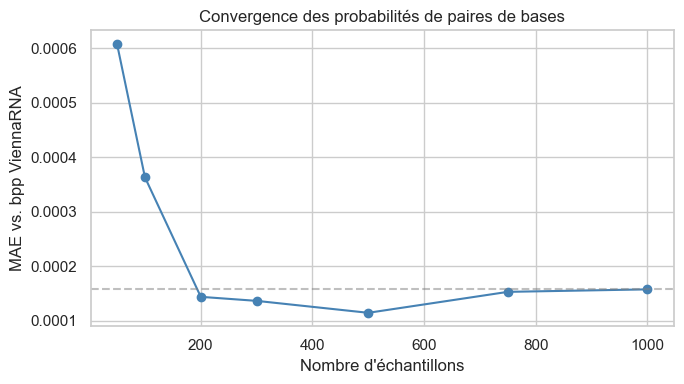

In [16]:
sample_sizes = [50, 100, 200, 300, 500, 750, 1000]
all_structs = df_samples["structure"].tolist()

# Matrice de référence = ViennaRNA bpp (vérité terrain)
bpp_ref = np.array(fc.bpp())[1:, 1:]

errors = []
for n in sample_sizes:
    subset = all_structs[:n]
    emp_matrix = probability_matrix(subset)
    # Erreur = MAE entre matrice empirique et référence ViennaRNA
    mae = np.mean(np.abs(emp_matrix - bpp_ref))
    errors.append(mae)

plt.figure(figsize=(7, 4))
plt.plot(sample_sizes, errors, marker="o", color="steelblue")
plt.xlabel("Nombre d'échantillons")
plt.ylabel("MAE vs. bpp ViennaRNA")
plt.title("Convergence des probabilités de paires de bases")
plt.axhline(errors[-1], linestyle="--", color="gray", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Clustering

### 5a. K-means clustering by Kmedoids

In [56]:
print(f"Structures uniques : {df_samples['structure'].nunique()}")
print(df_samples['structure'].value_counts().head(5))
print(f"Séquence utilisée : {sequence}")

Structures uniques : 75
structure
..(((((........)))))(((((((...)))))))...    686
...((((........)))).(((((((...)))))))...     75
..(((((........)))))((((((.....))))))...     60
.............(((....(((((((...))))))))))     24
.(((..((....)).)))..(((((((...)))))))...     15
Name: count, dtype: int64
Séquence utilisée : GAGUAGUGGAACCAGGCUAUGUUUGUGACUCGCAGACCCU


In [54]:
N_CLUSTERS = 3

kmed = KMedoids(n_clusters=N_CLUSTERS, metric="precomputed", random_state=42)
df_samples["cluster"] = kmed.fit_predict(dist_bp)

print(df_samples["cluster"].value_counts())
print(f"Medoids (indices) : {kmed.medoid_indices_}")
print(f"Structures médoïdes :")
for i, idx in enumerate(kmed.medoid_indices_):
    print(f"  Cluster {i} : {df_samples['structure'].iloc[idx]}")

cluster
0    1000
Name: count, dtype: int64
Medoids (indices) : [0 1 2]
Structures médoïdes :
  Cluster 0 : ..(((((........)))))(((((((...)))))))...
  Cluster 1 : ..(((((........)))))(((((((...)))))))...
  Cluster 2 : ..(((((........)))))(((((((...)))))))...


/Users/belineyuan/miniconda3/envs/alignment/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/Users/belineyuan/miniconda3/envs/alignment/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


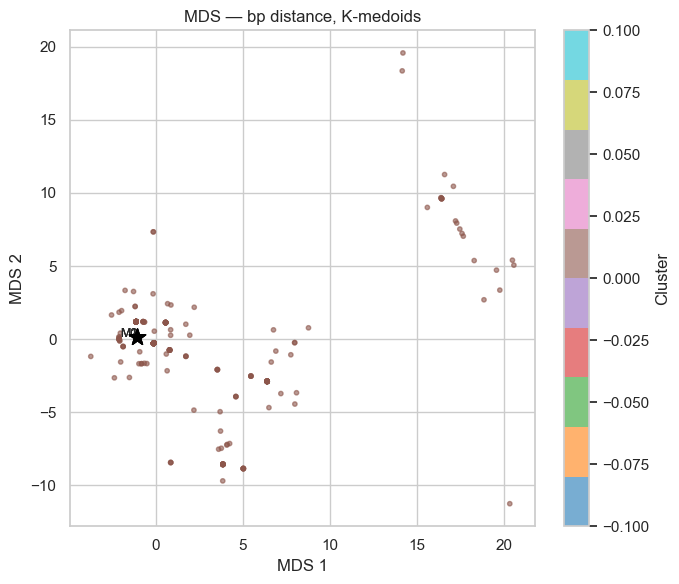

In [55]:
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_2d = mds.fit_transform(dist_bp)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=df_samples["cluster"], cmap="tab10", s=10, alpha=0.6
)
# Marquer les médoïdes
for i, idx in enumerate(kmed.medoid_indices_):
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=150, marker="*",
                color="black", zorder=5)
    plt.annotate(f"M{i}", (X_2d[idx, 0], X_2d[idx, 1]),
                 fontsize=9, ha="right")

plt.colorbar(scatter, label="Cluster")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")
plt.title("MDS — bp distance, K-medoids")
plt.tight_layout()
plt.show()

### 5b. Hierarchical (agglomerative) clustering (on edit distance matrix)

In [43]:
agg = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    metric="precomputed",
    linkage="average",
)
labels_agg = agg.fit_predict(dist_hamming)

df_samples["cluster_hierarchical"] = labels_agg
print("Hierarchical cluster assignments:")
print(df_samples[["structure", "cluster_hierarchical"]].to_string(index=False))

Hierarchical cluster assignments:
                               structure  cluster_hierarchical
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
.(((..((....)).)))..(((((((...)))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))((((((.....))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))(((((((...)))))))...                     0
..(((((........)))))(

### 5x. utilisation de bp distance

In [27]:
# Option 1 : clustering hiérarchique (déjà dans le notebook, ça marche directement)
agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, metric="precomputed", linkage="average")
labels = agg.fit_predict(dist_bp)

# Option 2 : K-medoids (adapté aux distances arbitraires)
from sklearn_extra.cluster import KMedoids

kmed = KMedoids(n_clusters=N_CLUSTERS, metric="precomputed", random_state=42)
labels = kmed.fit_predict(dist_bp)

/Users/belineyuan/miniconda3/envs/alignment/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/Users/belineyuan/miniconda3/envs/alignment/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


## 6. Evaluation

### 6a. Silhouette score

In [33]:
sil_kmeans = silhouette_score(X, labels_kmeans)
sil_agg    = silhouette_score(dist_hamming, labels_agg, metric="precomputed")

print(f"Silhouette score – K-means (Euclidean features): {sil_kmeans:.3f}")
print(f"Silhouette score – Hierarchical (edit distance): {sil_agg:.3f}")

Silhouette score – K-means (Euclidean features): 0.784
Silhouette score – Hierarchical (edit distance): 0.884


### 6b. Choosing the number of clusters – elbow method

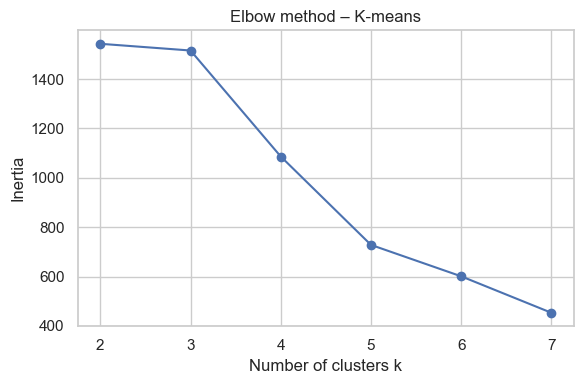

In [45]:
inertias = []
k_range = range(2, min(len(df_samples), 8))
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow method – K-means")
plt.tight_layout()
plt.show()

## 7. Visualisation

### 7a. PCA projection coloured by K-means cluster

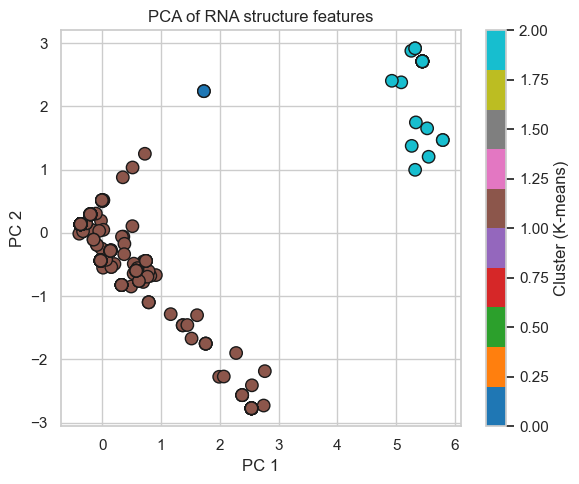

In [44]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=labels_kmeans, cmap="tab10", s=80, edgecolors="k"
)
plt.colorbar(scatter, label="Cluster (K-means)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA of RNA structure features")
plt.tight_layout()
plt.show()

### 7c. Dendrogram (hierarchical clustering)

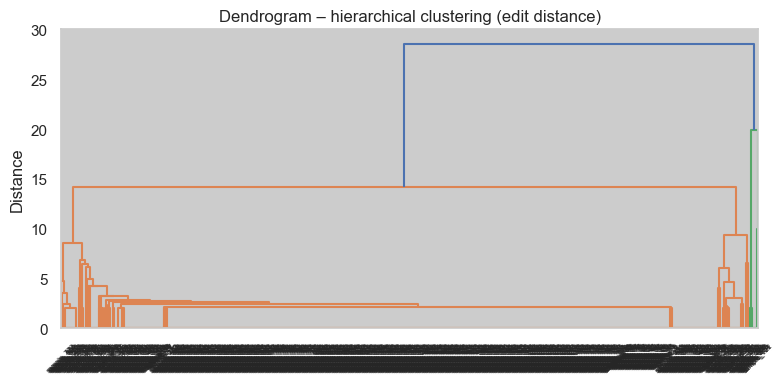

In [ ]:
condensed = squareform(dist_hamming)
Z = linkage(condensed, method="average")
df_samples["name"] = ["sample_" + str(i) for i in range(len(df_samples))]

plt.figure(figsize=(8, 4))
dendrogram(Z, labels=df_samples["name"].tolist(), leaf_rotation=45)
plt.title("Dendrogram – hierarchical clustering (edit distance)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()